# Task 0: Setting up Ollama

This task demonstrates how Ollama was installed and connected locally using Python.

Two Gemma 3 models were tested:
- gemma3:270m
- gemma3:4b

The models were used successfully to generate responses from prompts.

In [1]:
import ollama

In [2]:
response_270m = ollama.chat(
    model='gemma3:270m',
    messages=[
        {
            'role': 'user',
            'content': 'Explain machine learning in one sentence.'
        }
    ]
)

print(response_270m['message']['content'])

Machine learning is a subfield of artificial intelligence that uses algorithms to learn from data without explicit programming, enabling computers to make predictions, decisions, and solve problems more efficiently.



In [3]:
response_4b = ollama.chat(
    model='gemma3:4b',
    messages=[
        {
            'role': 'user',
            'content': 'Explain what a large language model is in one sentence.'
        }
    ]
)

print(response_4b['message']['content'])

A large language model is a sophisticated artificial intelligence that has been trained on a massive amount of text data to understand and generate human-like text.


# Task 1: Text Classification with Ollama

This task uses the `data/emails.csv` dataset, which contains 12 email headlines.

The objective is to classify each email headline into one of three categories:
- spam
- work
- unknown

In [6]:
with open("data/emails.csv", "r", encoding="utf-8") as file:
    lines = file.readlines()

headlines = []

for line in lines[1:]:
    clean_line = line.strip()
    headlines.append(clean_line)

emails_df = pd.DataFrame(headlines, columns=["headline"])

display(emails_df.head())

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review


## Task 1a: Email classification function

The following function sends one email headline to an Ollama model and asks it to classify the headline as spam, work, or unknown.

The function returns only the classification label.

In [10]:
def classify_email_headline(headline, model_name):
    prompt = f"""
You classify email subject lines.

Choose exactly one label:
spam
work
unknown

Definitions:
spam = phishing, scam, prize, suspicious money request, adult content, or clearly unwanted promotional email.
work = clearly professional: meetings, reports, reviews, drafts, projects, budgets, or workplace communication.
unknown = vague subject line where the category cannot be confidently determined.

Return only one word: spam, work, or unknown.

Subject line:
{headline}
"""

    response = ollama.chat(
        model=model_name,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        options={
            "temperature": 0
        }
    )

    classification = response["message"]["content"].strip().lower()

    if classification in ["spam", "work", "unknown"]:
        return classification
    else:
        return "unknown"

In [11]:
test_headline = emails_df.loc[0, "headline"]

test_result = classify_email_headline(
    test_headline,
    "gemma3:270m"
)

print("Headline:", test_headline)
print("Classification:", test_result)

Headline: URGENT: Your account will be suspended within 24 hours
Classification: spam


## Task 1b: Classification using gemma3:270m

The smaller Gemma 3 model (270m parameters) is used to classify all email headlines.

In [12]:
classification_270m = []

for headline in emails_df["headline"]:
    
    result = classify_email_headline(
        headline,
        "gemma3:270m"
    )
    
    classification_270m.append(result)

emails_df["classification_270m"] = classification_270m

display(emails_df)

,headline,classification_270m
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,spam
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,spam


### Comment on the 270m model

The gemma3:270m model classified almost all email headlines as spam, even after prompt adjustments.

This likely happened because the 270m model is extremely small and has limited reasoning and contextual understanding capabilities. The model appears to overgeneralize suspicious patterns and struggles to distinguish professional or vague email headlines from spam.

This demonstrates one limitation of very small language models when performing classification tasks.

## Task 1c: Classification using gemma3:4b

The larger Gemma 3 model (4b parameters) is now used to classify the same email headlines.

The goal is to compare the quality of the classifications between the smaller and larger models.

In [13]:
classification_4b = []

for headline in emails_df["headline"]:
    
    result = classify_email_headline(
        headline,
        "gemma3:4b"
    )
    
    classification_4b.append(result)

emails_df["classification_4b"] = classification_4b

display(emails_df)

,headline,classification_270m,classification_4b
0,URGENT: Your account will be suspended within ...,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam
4,Meeting agenda for Thursday's project review,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work
6,Reminder: Annual performance review scheduled ...,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work
8,Quick question about last week,spam,unknown
9,Following up,spam,unknown


### Comparison between the 270m and 4b models

The gemma3:4b model produced significantly more accurate and balanced classifications than the gemma3:270m model.

The smaller 270m model classified almost all headlines as spam, even when the headlines were clearly work-related or ambiguous. This suggests that the smaller model has limited contextual understanding and struggles with nuanced classification tasks.

In contrast, the 4b model was better able to distinguish between spam, work, and unknown headlines. The larger model demonstrated stronger reasoning capabilities and better interpretation of context.

This comparison highlights how model size can strongly influence classification quality and reliability.

## Task 1d: Repeating classifications multiple times

This task repeats the classification process three times for both models in order to analyze the consistency and variability of the outputs.

In [14]:
def classify_email_random(headline, model_name):
    prompt = f"""
You classify email subject lines.

Choose exactly one label:
spam
work
unknown

Return only one word.

Subject line:
{headline}
"""

    response = ollama.chat(
        model=model_name,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        options={
            "temperature": 0.7
        }
    )

    classification = response["message"]["content"].strip().lower()

    if "spam" in classification:
        return "spam"
    elif "work" in classification:
        return "work"
    elif "unknown" in classification:
        return "unknown"
    else:
        return "unknown"

In [15]:
results_270m = pd.DataFrame()

results_270m["headline"] = emails_df["headline"]

for run in range(1, 4):
    
    classifications = []
    
    for headline in emails_df["headline"]:
        
        result = classify_email_random(
            headline,
            "gemma3:270m"
        )
        
        classifications.append(result)
    
    results_270m[f"run_{run}"] = classifications

display(results_270m)

,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,unknown,unknown,unknown
1,Congratulations! You have won a 1000€ gift car...,unknown,unknown,unknown
2,Hot singles in your area are waiting to meet y...,unknown,unknown,unknown
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,unknown,unknown
4,Meeting agenda for Thursday's project review,unknown,unknown,unknown
5,"Q3 budget report attached, please review by Fr...",unknown,unknown,unknown
6,Reminder: Annual performance review scheduled ...,unknown,unknown,unknown
7,"Updated draft of the manuscript, comments welcome",unknown,unknown,unknown
8,Quick question about last week,unknown,unknown,unknown
9,Following up,unknown,unknown,unknown


In [16]:
results_4b = pd.DataFrame()

results_4b["headline"] = emails_df["headline"]

for run in range(1, 4):
    
    classifications = []
    
    for headline in emails_df["headline"]:
        
        result = classify_email_random(
            headline,
            "gemma3:4b"
        )
        
        classifications.append(result)
    
    results_4b[f"run_{run}"] = classifications

display(results_4b)

,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,work,work
4,Meeting agenda for Thursday's project review,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,work
8,Quick question about last week,unknown,unknown,unknown
9,Following up,work,work,work


### Comment on repeated classifications

The repeated runs showed that the outputs of the models were not always identical.

The smaller 270m model showed greater inconsistency and lower classification quality, while the 4b model produced more stable and coherent results across runs.

These differences occur because language models use probabilistic token generation. When temperature is increased, the model introduces more randomness into the responses, which can lead to variations between runs.

# Task 2: Sentiment Analysis with Ollama

This task uses the `data/news.csv` dataset, which contains 10 fictional financial news headlines.

The objective is to classify each headline by:
- topic: earnings, mergers, regulation, macroeconomics
- sentiment: positive, negative, neutral

In [17]:
with open("data/news.csv", "r", encoding="utf-8") as file:
    lines = file.readlines()

news_headlines = []

for line in lines[1:]:
    clean_line = line.strip()
    news_headlines.append(clean_line)

news_df = pd.DataFrame(news_headlines, columns=["headline"])

display(news_df.head())

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...


## Task 2a: Topic and sentiment classification function

The following function classifies a financial news headline by topic and sentiment.

The function returns the result in JSON format.

In [18]:
import json

def classify_news_headline(headline, model_name="gemma3:4b"):
    prompt = f"""
You classify fictional financial news headlines.

Choose exactly one topic:
earnings
mergers
regulation
macroeconomics

Choose exactly one sentiment:
positive
negative
neutral

Return only valid JSON in this format:
{{"topic": "topic_here", "sentiment": "sentiment_here"}}

Headline:
{headline}
"""

    response = ollama.chat(
        model=model_name,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        options={
            "temperature": 0
        }
    )

    result_text = response["message"]["content"].strip()

    return result_text

In [19]:
test_news = news_df.loc[0, "headline"]

test_result = classify_news_headline(test_news)

print(test_news)
print(test_result)

Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
{"topic": "earnings", "sentiment": "positive"}


In [20]:
topics = []
sentiments = []

for headline in news_df["headline"]:
    
    result_text = classify_news_headline(headline)
    
    result_json = json.loads(result_text)
    
    topics.append(result_json["topic"])
    sentiments.append(result_json["sentiment"])

news_results_df = news_df.copy()

news_results_df["topic"] = topics
news_results_df["sentiment"] = sentiments

display(news_results_df)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,mergers,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


## Task 2c: Comparison with a browser-based LLM

The same financial news headlines were also classified using ChatGPT as a browser-based LLM, with the same topic and sentiment options.

| Headline | ChatGPT topic | ChatGPT sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | positive |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

Overall, the ChatGPT classifications were very similar to the Ollama gemma3:4b results. Both models correctly identified most topics and sentiments.

ChatGPT appeared slightly more reliable for ambiguous cases, especially where the headline could belong to more than one category. For example, merger-related headlines involving regulators can be interpreted as either mergers or regulation, depending on the focus of the classification. ChatGPT was generally better at using the main business event of the headline as the topic.

In conclusion, the local Ollama model performed well on this small dataset, but the browser-based LLM was slightly more consistent and easier to interpret. This is likely because browser-based LLMs are usually larger and have stronger language understanding than the smaller local model used in Ollama.

# Task 3: Supervised Machine Learning

This task uses the Bank Marketing dataset from the UCI Machine Learning Repository.

The goal is to predict whether a prospective customer will subscribe to a term deposit.

The target variable is `y`.

In [56]:
from IPython.display import display

In [57]:
bank_df = pd.read_csv("data/bank-additional/bank-additional.csv", sep=";")

bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [58]:
print("Dataset shape:")
print(bank_df.shape)

print("\nColumn names:")
print(bank_df.columns)

print("\nDataset information:")
bank_df.info()

Dataset shape:
(4119, 21)

Column names:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   obj

In [59]:
print("Missing values per column:")
print(bank_df.isnull().sum())

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [60]:
print("Target variable distribution:")
display(bank_df["y"].value_counts())

print("\nTarget variable distribution in percentage:")
display(bank_df["y"].value_counts(normalize=True) * 100)

Target variable distribution:


y
no     3668
yes     451
Name: count, dtype: int64


Target variable distribution in percentage:


y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64

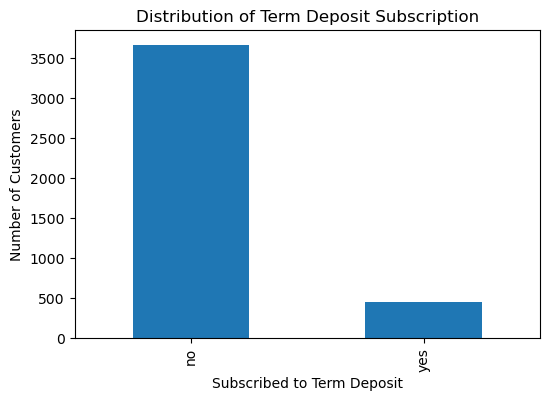

In [61]:
plt.figure(figsize=(6, 4))

bank_df["y"].value_counts().plot(kind="bar")

plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")

plt.show()

## Task 3b: Data Preprocessing

The target variable `y` is categorical, with two possible values: `yes` and `no`.

The preprocessing steps are:
- Separate features and target variable
- Convert the target variable into binary values
- Identify numerical and categorical columns
- Scale numerical variables
- One-hot encode categorical variables

In [62]:
X = bank_df.drop("y", axis=1)
y = bank_df["y"]

y = y.map({
    "no": 0,
    "yes": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(y.value_counts())

Features shape: (4119, 20)
Target shape: (4119,)


y
0    3668
1     451
Name: count, dtype: int64

In [63]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numerical_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Task 3c: Model Selection and Training

This is a classification task because the target variable `y` has two possible categories:
- `yes`: the customer subscribed to a term deposit
- `no`: the customer did not subscribe

Three supervised machine learning algorithms are used:

1. Logistic Regression  
This model is a simple and interpretable baseline for binary classification.

2. Decision Tree Classifier  
This model can capture non-linear relationships and is easy to interpret.

3. Random Forest Classifier  
This model combines multiple decision trees and usually performs better and more robustly than a single tree.

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_validation.shape)
print("Test set:", X_test.shape)

Training set: (2471, 20)
Validation set: (824, 20)
Test set: (824, 20)


In [66]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

In [67]:
def evaluate_model(model, X_data, y_data):
    predictions = model.predict(X_data)
    
    accuracy = accuracy_score(y_data, predictions)
    precision = precision_score(y_data, predictions, zero_division=0)
    recall = recall_score(y_data, predictions, zero_division=0)
    f1 = f1_score(y_data, predictions, zero_division=0)
    
    return accuracy, precision, recall, f1

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [69]:
logistic_results = []

for C_value in [0.1, 1, 10]:
    
    logistic_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                C=C_value,
                max_iter=1000,
                class_weight="balanced"
            ))
        ]
    )
    
    logistic_model.fit(X_train, y_train)
    
    accuracy, precision, recall, f1 = evaluate_model(
        logistic_model,
        X_validation,
        y_validation
    )
    
    logistic_results.append([C_value, accuracy, precision, recall, f1])

logistic_results_df = pd.DataFrame(
    logistic_results,
    columns=["C", "Accuracy", "Precision", "Recall", "F1"]
)

display(logistic_results_df)

,C,Accuracy,Precision,Recall,F1
0,0.1,0.872573,0.453988,0.822222,0.584980
1,1.0,0.877427,0.464516,0.800000,0.587755
2,10.0,0.877427,0.464052,0.788889,0.584362


In [70]:
tree_results = []

for depth in [3, 5, 10, None]:
    
    tree_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", DecisionTreeClassifier(
                max_depth=depth,
                random_state=42,
                class_weight="balanced"
            ))
        ]
    )
    
    tree_model.fit(X_train, y_train)
    
    accuracy, precision, recall, f1 = evaluate_model(
        tree_model,
        X_validation,
        y_validation
    )
    
    tree_results.append([depth, accuracy, precision, recall, f1])

tree_results_df = pd.DataFrame(
    tree_results,
    columns=["Max Depth", "Accuracy", "Precision", "Recall", "F1"]
)

display(tree_results_df)

,Max Depth,Accuracy,Precision,Recall,F1
0,3.0,0.849515,0.406593,0.822222,0.544118
1,5.0,0.847087,0.402174,0.822222,0.540146
2,10.0,0.848301,0.368421,0.544444,0.439462
3,NaN,0.887136,0.480519,0.411111,0.443114


In [71]:
forest_results = []

for number_of_trees in [50, 100]:
    for depth in [5, 10, None]:
        
        forest_model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", RandomForestClassifier(
                    n_estimators=number_of_trees,
                    max_depth=depth,
                    random_state=42,
                    class_weight="balanced"
                ))
            ]
        )
        
        forest_model.fit(X_train, y_train)
        
        accuracy, precision, recall, f1 = evaluate_model(
            forest_model,
            X_validation,
            y_validation
        )
        
        forest_results.append([
            number_of_trees,
            depth,
            accuracy,
            precision,
            recall,
            f1
        ])

forest_results_df = pd.DataFrame(
    forest_results,
    columns=["Number of Trees", "Max Depth", "Accuracy", "Precision", "Recall", "F1"]
)

display(forest_results_df)

,Number of Trees,Max Depth,Accuracy,Precision,Recall,F1
0,50,5.0,0.877427,0.457364,0.655556,0.538813
1,50,10.0,0.894417,0.516484,0.522222,0.519337
2,50,NaN,0.908981,0.777778,0.233333,0.358974
3,100,5.0,0.873786,0.450704,0.711111,0.551724
4,100,10.0,0.895631,0.521277,0.544444,0.532609
5,100,NaN,0.907767,0.750000,0.233333,0.355932


In [72]:
best_logistic_row = logistic_results_df.sort_values("F1", ascending=False).iloc[0]
best_tree_row = tree_results_df.sort_values("F1", ascending=False).iloc[0]
best_forest_row = forest_results_df.sort_values("F1", ascending=False).iloc[0]

print("Best Logistic Regression parameters:")
display(best_logistic_row)

print("Best Decision Tree parameters:")
display(best_tree_row)

print("Best Random Forest parameters:")
display(best_forest_row)

Best Logistic Regression parameters:


C            1.000000
Accuracy     0.877427
Precision    0.464516
Recall       0.800000
F1           0.587755
Name: 1, dtype: float64

Best Decision Tree parameters:


Max Depth    3.000000
Accuracy     0.849515
Precision    0.406593
Recall       0.822222
F1           0.544118
Name: 0, dtype: float64

Best Random Forest parameters:


Number of Trees    100.000000
Max Depth            5.000000
Accuracy             0.873786
Precision            0.450704
Recall               0.711111
F1                   0.551724
Name: 3, dtype: float64

## Task 3d: Train/Validation/Test Split vs Cross-Validation

This section compares two model evaluation approaches:

1. Train/validation/test split  
   The model is trained on a training set, tuned on a validation set, and finally evaluated on a test set.

2. Cross-validation  
   The training data is split several times into different folds. This gives a more stable estimate of model performance.

The F1-score is used for comparison because the target variable is imbalanced.

In [73]:
best_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            C=1,
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

best_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

best_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [74]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

print("Training set:", X_train.shape)
print("Validation set:", X_validation.shape)
print("Test set:", X_test.shape)

Training set: (2471, 20)
Validation set: (824, 20)
Test set: (824, 20)


In [75]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": best_logistic_model,
    "Decision Tree": best_tree_model,
    "Random Forest": best_forest_model
}

cross_validation_results = []

for model_name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train_full,
        y_train_full,
        cv=5,
        scoring="f1"
    )
    
    cross_validation_results.append([
        model_name,
        scores.mean(),
        scores.std()
    ])

cross_validation_df = pd.DataFrame(
    cross_validation_results,
    columns=["Model", "Mean F1 Cross-Validation", "Standard Deviation"]
)

display(cross_validation_df)

,Model,Mean F1 Cross-Validation,Standard Deviation
0,Logistic Regression,0.587134,0.030295
1,Decision Tree,0.534872,0.026443
2,Random Forest,0.569444,0.034656


In [76]:
validation_comparison_results = []

for model_name, model in models.items():
    
    model.fit(X_train, y_train)
    
    accuracy, precision, recall, f1 = evaluate_model(
        model,
        X_validation,
        y_validation
    )
    
    validation_comparison_results.append([
        model_name,
        f1
    ])

validation_comparison_df = pd.DataFrame(
    validation_comparison_results,
    columns=["Model", "F1 Validation Set"]
)

display(validation_comparison_df)

,Model,F1 Validation Set
0,Logistic Regression,0.592885
1,Decision Tree,0.548872
2,Random Forest,0.593023


In [77]:
evaluation_comparison_df = validation_comparison_df.merge(
    cross_validation_df,
    on="Model"
)

display(evaluation_comparison_df)

,Model,F1 Validation Set,Mean F1 Cross-Validation,Standard Deviation
0,Logistic Regression,0.592885,0.587134,0.030295
1,Decision Tree,0.548872,0.534872,0.026443
2,Random Forest,0.593023,0.569444,0.034656


## Task 3e: Final Model Evaluation

This section evaluates the final performance of the three selected models on the test set.

Several classification metrics are used:
- Accuracy
- Precision
- Recall
- F1-score

Because the dataset is imbalanced, F1-score and recall are especially important.

In [78]:
final_results = []

for model_name, model in models.items():
    
    model.fit(X_train_full, y_train_full)
    
    accuracy, precision, recall, f1 = evaluate_model(
        model,
        X_test,
        y_test
    )
    
    final_results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

final_results_df = pd.DataFrame(
    final_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)

display(final_results_df)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.875000,0.460123,0.833333,0.592885
1,Decision Tree,0.862864,0.433526,0.833333,0.570342
2,Random Forest,0.908981,0.590361,0.544444,0.566474


In [47]:
best_model_name = final_results_df.sort_values("F1", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train_full, y_train_full)

test_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)

Best model: Logistic Regression


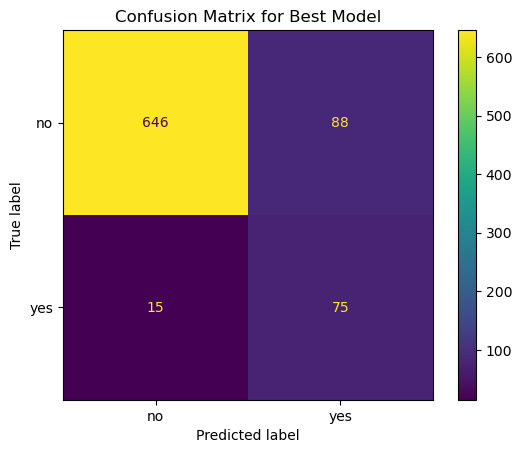

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_test, test_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=["no", "yes"]
)

display.plot()

plt.title("Confusion Matrix for Best Model")
plt.show()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_predictions,
    target_names=["no", "yes"],
    zero_division=0
))

              precision    recall  f1-score   support

          no       0.98      0.88      0.93       734
         yes       0.46      0.83      0.59        90

    accuracy                           0.88       824
   macro avg       0.72      0.86      0.76       824
weighted avg       0.92      0.88      0.89       824



### Final evaluation comment

The models were evaluated using accuracy, precision, recall and F1-score.

Accuracy is useful, but it is not sufficient for this dataset because the target variable is imbalanced. Most customers did not subscribe to a term deposit, so a model could achieve high accuracy by mostly predicting the majority class.

For this reason, F1-score and recall are more informative metrics. Recall is important because it measures how well the model identifies customers who actually subscribed.

Based on the final test set results, the best model is the one with the highest F1-score. This model provides the best balance between precision and recall for predicting term deposit subscription.